In [1]:
import sys
import pathlib

# Get project root (parent of generation/)
project_root = pathlib.Path().resolve().parent
sys.path.insert(0, str(project_root))

### Manifesto

In [41]:
from scripts.utils.logger import logger

In [42]:
logger_params = {
    "main_folder": "/home/think/Desktop/MOCK",
    "experiment_name": "Zero-Shot",
    "date": "2025-09-09",
    "iteration": 1,
    "description": (
        "Se entrenara una CNN con lorenz63 en diferentes"
        "regimenes caoticos, en cada caso"
        "se testeara si puede reconstruir para diferentes "
        "condiciones inciales asi como su Zero-Shot power"
    )
}

In [43]:
exp_folder, manifesto_path = logger(logger_params)
print(f"Experiment folder created at: {exp_folder}")
print(f"Manifesto written to: {manifesto_path}")

Experiment folder created at: /home/think/Desktop/MOCK/Zero-Shot_2025-09-09_iter1
Manifesto written to: /home/think/Desktop/MOCK/Zero-Shot_2025-09-09_iter1/manifesto.txt


In [2]:
from scripts.data_generation.binder import Binder
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scripts.data_generation.tsdg import DynamicalSystem

### Data

In [243]:
model_name = 'lorenz63'

sigma = 10 
beta = 8/3
rho = 28
params = (sigma, beta, rho)


binder = Binder("scripts.systems.lorenz63", "lorenz63", params)
binder.import_module()      
model_fixed = binder.fixer()


t_span = (0, 100)
t_eval = np.linspace(t_span[0], t_span[1], 10000)
y0 = np.array([0.1, 0.1, 0.1])

ds1 = DynamicalSystem(model_fixed, y0, t_eval, notebook = True)
_ = ds1.solve()
eps = 50
y0_perturbed = y0 + eps
ds2 = DynamicalSystem(model_fixed, y0_perturbed, t_eval, notebook=True)
_ = ds2.solve()

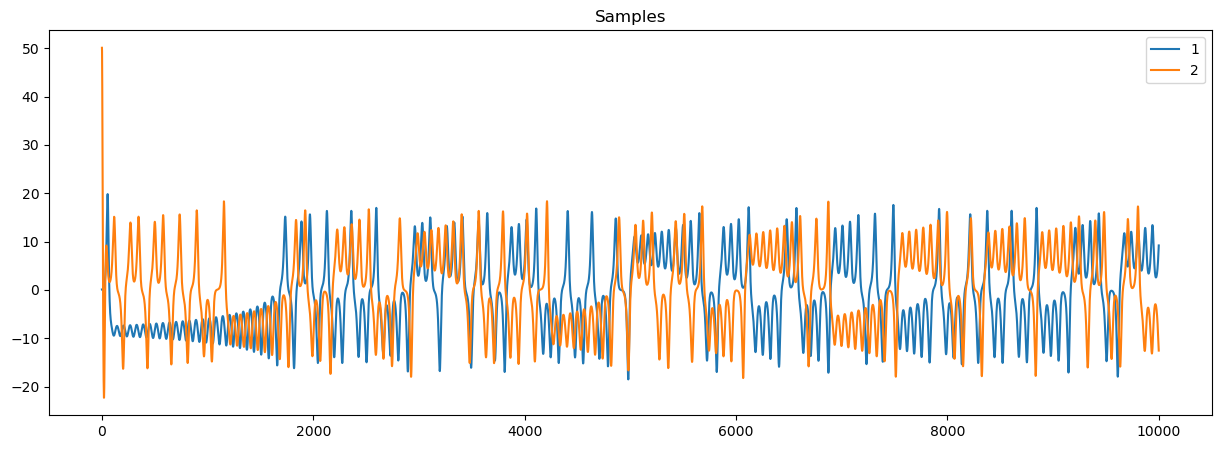

In [244]:
# Plot scaled
plt.figure(figsize=(15,5))
plt.plot(ds1.solution.y[0], label = '1')
plt.plot(ds2.solution.y[0], label = '2')
#plt.xlim(0,4000)
plt.title('Samples')
plt.legend()
plt.show()

### Scaling

In [245]:
sample_1 = ds1.to_dataframe()
sample_2 = ds2.to_dataframe()
sample_1 = sample_1[['x']]
sample_2 = sample_2[['x']]
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
sample_1_scaled = pd.DataFrame(scaler.fit_transform(sample_1), columns = ['x'])
sample_2_scaled = pd.DataFrame(scaler.fit_transform(sample_2), columns = ['x'])

### Training and Test Split

In [246]:
# Sample_1
Full_1 = sample_1_scaled['x'].values
n_samples_1 = len(Full_1)
train_size_1 = int(0.50 * n_samples_1)
train_data_1 = Full_1[:train_size_1]
test_data_1 = Full_1[train_size_1:]
# Sample_2
Full_2 = sample_2_scaled['x'].values
n_samples_2 = len(Full_2)
train_size_2 = int(0.50 * n_samples_2)
train_data_2 = Full_2[:train_size_2]
test_data_2 = Full_2[train_size_2:]

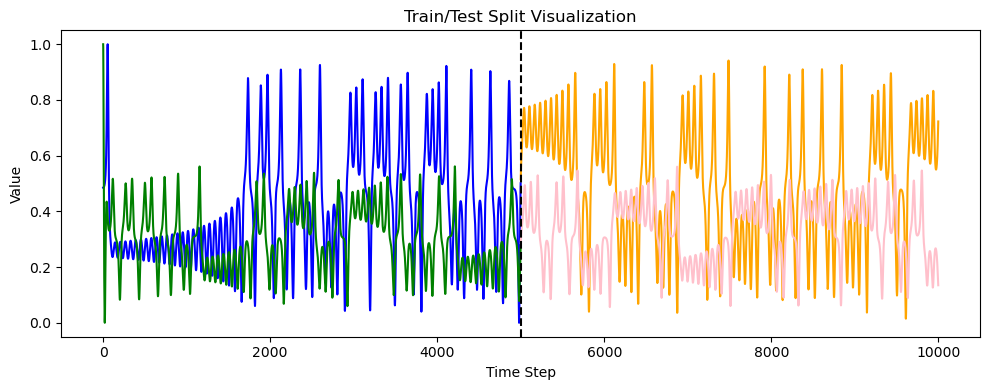

In [247]:
# Define x-axis ranges based on the lengths
train_end = len(train_data_1)
x_train = np.arange(train_end)
x_test = np.arange(train_end, train_end + len(test_data_1))
# Plot
plt.figure(figsize=(10, 4))
plt.plot(x_train, train_data_1, label='Train', color='blue')
plt.plot(x_train, train_data_2, label='Train', color='green')
plt.plot(x_test, test_data_1, label='Test', color='orange')
plt.plot(x_test, test_data_2, label='Test', color='pink')

# Optional vertical line to indicate the split
plt.axvline(x=train_end, color='black', linestyle='--', label='Train/Test Split')

#plt.legend()
plt.title("Train/Test Split Visualization")
plt.xlabel("Time Step")
plt.ylabel("Value")
plt.tight_layout()
plt.show()

### Prepare Data for the Model

In [146]:
# univariate data preparation
from numpy import array

#split a univariate sequence into samples
def split_sequence(sequence, n_steps):
    X, y = list(), list()
    for i in range(len(sequence)):
        # find the end of this pattern
        end_ix = i +n_steps
        if end_ix > len(sequence) - 1:
            break
        #gather input and output parts of the pattern
        seq_x, seq_y = sequence[i:end_ix], sequence[end_ix]
        X.append(seq_x)
        y.append(seq_y)
    return array(X), array(y)

In [148]:
# choose a number of time steps
n_steps = 1
# split into samples
X, y = split_sequence(train_data_1, n_steps)   

In [ ]:
# summarize the data
for i in range(len(X)):
    print(X[i],y[i])

In [150]:
# reshape from [samples, timesteps] into [samples, timesteps, features]
n_features = 1
X = X.reshape((X.shape[0], X.shape[1], n_features))

### Model

In [151]:
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Flatten
from keras.layers import Conv1D
from keras.layers import MaxPooling1D

In [152]:
# define model
model = Sequential()
model.add(Conv1D(64, kernel_size=1, activation = 'relu', input_shape=(n_steps, n_features)))
#model.add(MaxPooling1D())
model.add(Flatten())
model.add(Dense(50, activation='relu'))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

/home/think/anaconda3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [153]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6),
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
]

In [154]:
history = model.fit(X, y,
                    epochs=300,
                    batch_size=64,
                    validation_split=0.1,
                    shuffle=False,
                    callbacks=callbacks,
                    verbose=1)

Epoch 1/300
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1053 - val_loss: 0.0085 - learning_rate: 0.0010
Epoch 2/300
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0063 - val_loss: 0.0031 - learning_rate: 0.0010
Epoch 3/300
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0020 - val_loss: 0.0011 - learning_rate: 0.0010
Epoch 4/300
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.6614e-04 - val_loss: 4.5201e-04 - learning_rate: 0.0010
Epoch 5/300
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.3784e-04 - val_loss: 3.1771e-04 - learning_rate: 0.0010
Epoch 6/300
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0624e-04 - val_loss: 2.8340e-04 - learning_rate: 0.0010
Epoch 7/300
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0186e-04 - val_loss: 2.6772e-04 - learning_rate: 0.0010
Epoch 8/300
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9.8963e-05 - val_loss: 2.5593e-04 - learning_rate: 0.0010
Epoch 9/300
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 9.6646e-05 - val_loss: 2.4536

### Save Model

In [155]:
import os
import json
import joblib
import tensorflow as tf
from pathlib import Path

def save_experiment(model, history, scaler=None,
                    name="experiment", save_dir=None,
                    use_h5=False):
    """
    Save model + history + optional scaler in {save_dir}/{name}/
    Options:
      - use_h5=True → HDF5 (.h5) single file
      - use_h5=False → Keras 3 format (.keras single file)
    """
    base = Path(save_dir or os.getcwd()) / name
    base.mkdir(parents=True, exist_ok=True)

    if use_h5:
        model_path = base / f"{name}.h5"
        model.save(model_path, save_format='h5')
        print(f"[+] Saved HDF5 model to {model_path.name}")
    else:
        model_path = base / f"{name}.keras"
        model.save(model_path)  # defaults to Keras v3 format
        print(f"[+] Saved Keras model to {model_path.name}")

    # Save history
    with open(base / "history.json", "w") as f:
        json.dump(history.history, f)

    # Save scaler
    if scaler is not None:
        joblib.dump(scaler, base / "scaler.pkl")

    return base, model_path

In [156]:
save_experiment(
  model, history,
  name="CNN_LORENZ_50",
  save_dir=exp_folder,
  use_h5=False
)

[+] Saved Keras model to CNN_LORENZ_50.keras


(PosixPath('/home/think/Desktop/MOCK/Zero-Shot_2025-09-09_iter1/CNN_LORENZ_50'),
 PosixPath('/home/think/Desktop/MOCK/Zero-Shot_2025-09-09_iter1/CNN_LORENZ_50/CNN_LORENZ_50.keras'))

### Reload Model

In [47]:
import os
import json
import joblib
import tensorflow as tf
from pathlib import Path

In [160]:
def reload_experiment(intro):
    """
    Prompts for folder path, loads:
      - model (.keras or .h5)
      - history.json
      - scaler.pkl (if exists)
    Returns: model, history_dict, scaler
    """
    path = Path((intro).strip()).expanduser()
    base = path / path.name  # prefer file inside named subfolder

    # Find model file
    mfile = next(path.glob("*.keras"), None) or next(path.glob("*.h5"), None)
    if mfile is None:
        raise FileNotFoundError("No `.keras` or `.h5` model found.")

    model = tf.keras.models.load_model(mfile)
    print(f"[+] Loaded model from {mfile.name}")

    # Load history
    history = json.load(open(path / "history.json"))
    print("[+] Loaded history.json")

    # Load scaler
    scaler = None
    skl = path / "scaler.pkl"
    if skl.exists():
        scaler = joblib.load(skl)
        print("[+] Loaded scaler.pkl")

    return model, history, scaler


In [161]:
# /home/think/Desktop/MODELS/CNN_OS_UV_1
path = '/home/think/Desktop/MOCK/Zero-Shot_2025-09-09_iter1/CNN_LORENZ_50'
model_CNN_OS_50, history_CNN_OS_50, scaler__CNN_OS_5O = reload_experiment(path)

[+] Loaded model from CNN_LORENZ_50.keras
[+] Loaded history.json


### Testing Learning

In [167]:
from sklearn import metrics
from scipy.stats import skew
import numpy as np

def predictions(true_data, model):
    # List to store predictions
    predictions = []

    # Loop to predict one step at a time
    for i in range(len(true_data)):
        # Initialize input, start with the first value of the training data
        uno = true_data[i]
        # reshape so we can feed it to the model
        uno = uno.reshape((1, n_steps, n_features)) 

        yhat = model.predict(uno, verbose=0)
        predictions.append(yhat[0, 0])

    # Convert predictions to numpy array
    predictions = np.array(predictions)
    return predictions

In [168]:
preds_mod_at_50 = predictions(train_data_1,model_CNN_OS_50 )

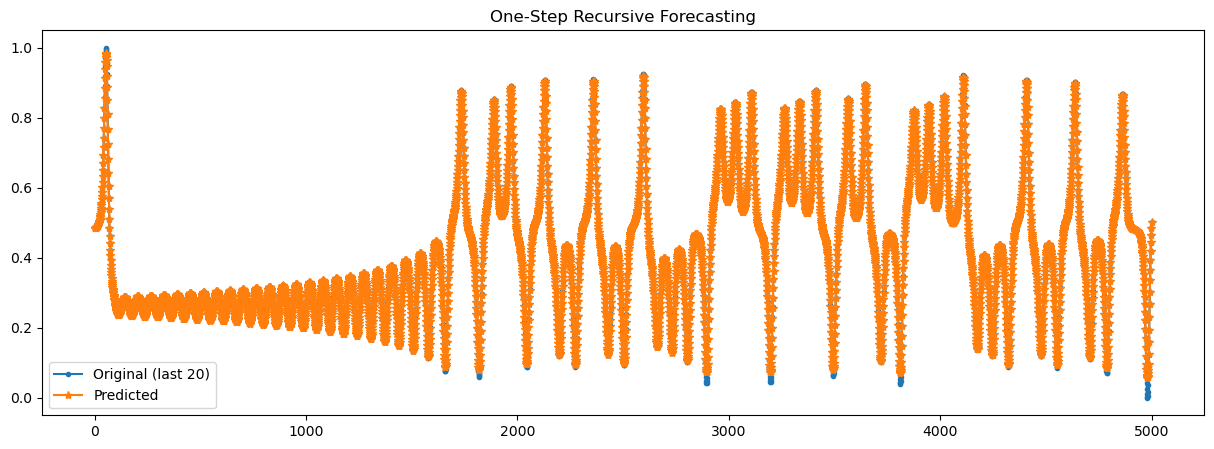

In [169]:
# Plot
plt.figure(figsize=(15,5))
plt.plot(train_data_1, label='Original (last 20)', marker='.')
plt.plot(preds_mod_at_50, label='Predicted', marker='*')
plt.legend()
#plt.xlim(0,20)
plt.title('One-Step Recursive Forecasting')
plt.show()

### Testing Learning on unseen Data from same system with same i.c

In [170]:
preds_unseen_mod_at_50 = predictions(test_data_1,model_CNN_OS_50 )

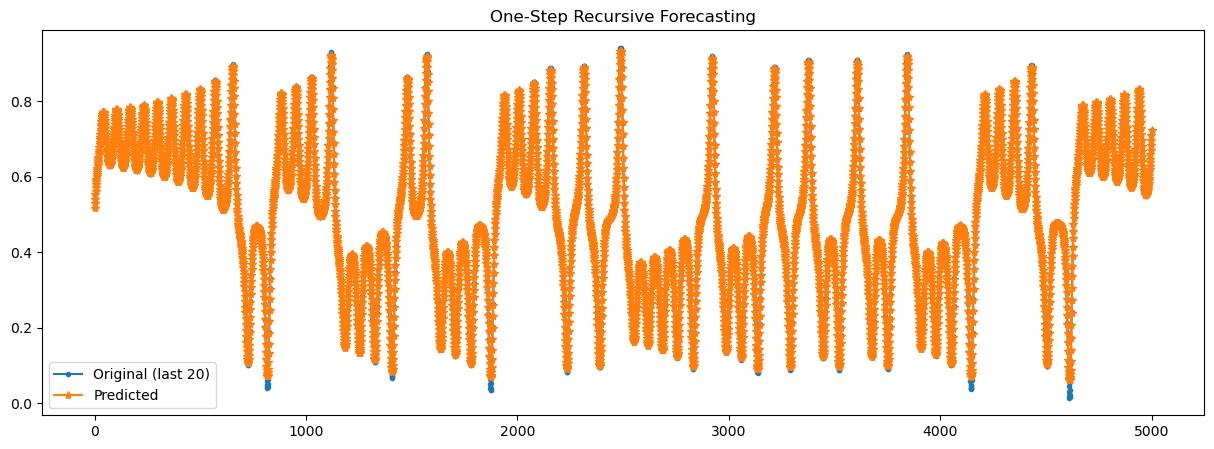

In [171]:
# Plot
plt.figure(figsize=(15,5))
plt.plot(test_data_1, label='Original (last 20)', marker='.')
plt.plot(preds_unseen_mod_at_50, label='Predicted', marker='*')
plt.legend()
#plt.xlim(0,20)
plt.title('One-Step Recursive Forecasting')
plt.show()

### Same as abpove but for sample2

In [248]:
preds_mod_at_50_sample_2 = predictions(train_data_2,model_CNN_OS_50 )

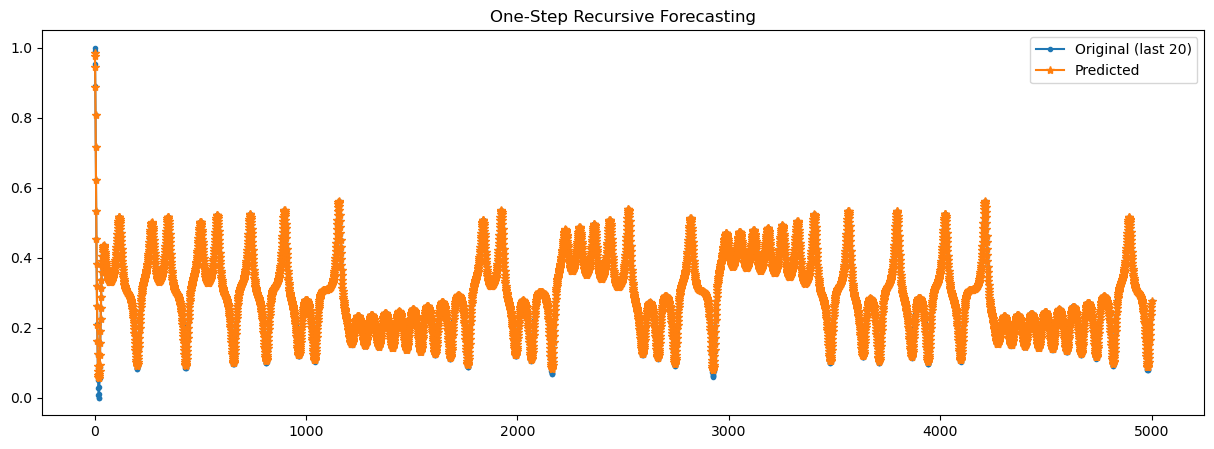

In [249]:
# Plot
plt.figure(figsize=(15,5))
plt.plot(train_data_2, label='Original (last 20)', marker='.')
plt.plot(preds_mod_at_50_sample_2, label='Predicted', marker='*')
plt.legend()
#plt.xlim(0,100)
plt.title('One-Step Recursive Forecasting')
plt.show()

In [250]:
preds_unseen_mod_at_50_sample_2 = predictions(test_data_2,model_CNN_OS_50 )

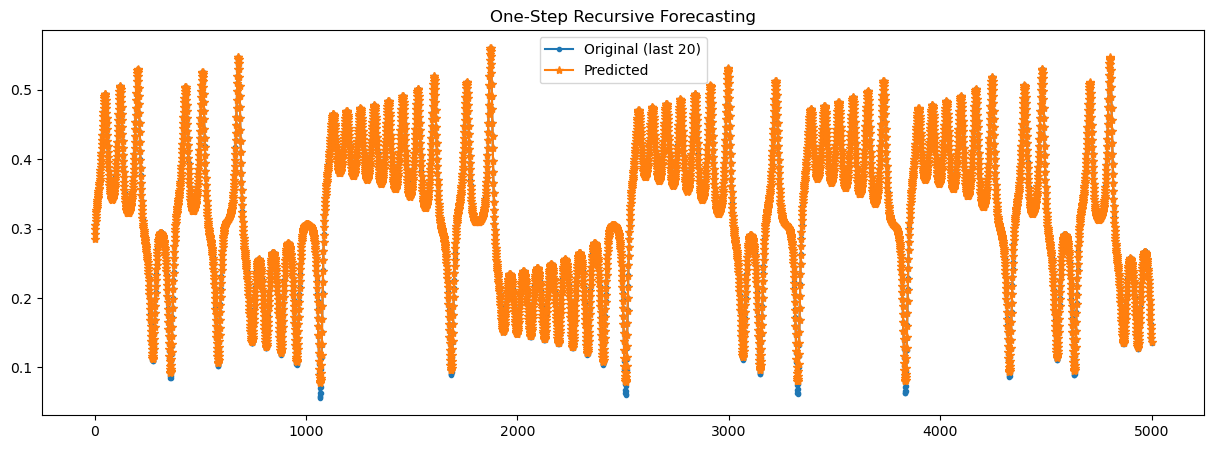

In [251]:
# Plot
plt.figure(figsize=(15,5))
plt.plot(test_data_2, label='Original (last 20)', marker='.')
plt.plot(preds_unseen_mod_at_50_sample_2, label='Predicted', marker='*')
plt.legend()
#plt.xlim(0,100)
plt.title('One-Step Recursive Forecasting')
plt.show()

### One Step forecasting on the same sample, outside the time horizon

### Sample 1

In [260]:
from sklearn import metrics
from scipy.stats import skew
import numpy as np


def recursive_OS_predictions(train_data, test_data, model):
    # Initialize input, start with the last value of the training data
    uno = train_data[-1]
    # reshape so we can feed it to the model
    uno = uno.reshape((1, n_steps, n_features)) 
    # List to store predictions
    predictions = []

    # Loop to predict one step at a time
    for i in range(len(test_data)):
        yhat = model.predict(uno, verbose=0)  
        predictions.append(yhat[0, 0])
        
        # update input to next step — use prediction as input
        uno = yhat.reshape((1, n_steps, n_features))

    # Convert predictions to numpy array
    predictions = np.array(predictions)
    return predictions

In [261]:
recurs_preds_1 = recursive_OS_predictions(train_data_1, test_data_1, model_CNN_OS_50)

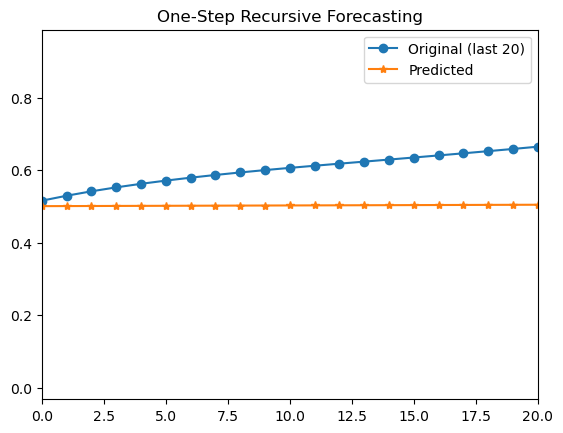

In [268]:
# Plot
plt.plot(test_data_1, label='Original (last 20)', marker='o')
plt.plot(recurs_preds_1, label='Predicted', marker='*')
plt.legend()
plt.xlim(0,20)
plt.title('One-Step Recursive Forecasting')
plt.show()

### Sample 2

In [266]:
recurs_preds_2 = recursive_OS_predictions(train_data_2, test_data_2, model_CNN_OS_50)

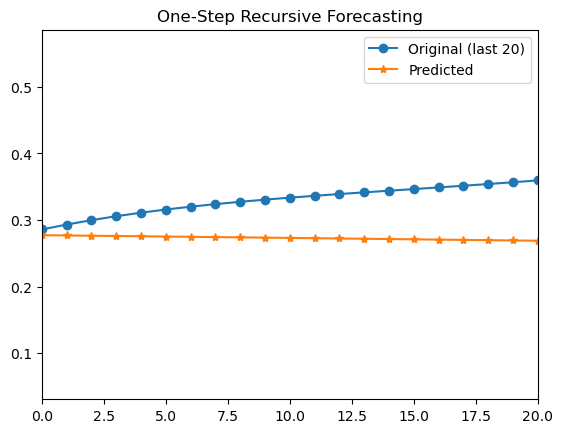

In [269]:
# Plot
plt.plot(test_data_2, label='Original (last 20)', marker='o')
plt.plot(recurs_preds_2, label='Predicted', marker='*')
plt.legend()
plt.xlim(0,20)
plt.title('One-Step Recursive Forecasting')
plt.show()